In [1]:
#Day 6, Topic 5: Rolling Windows

#Basic .rolling() Syntax
import pandas as pd
import numpy as np

# Create a simple daily time series
dates = pd.date_range('2024-01-01', periods=10, freq='D')
values = pd.Series([1, 3, 2, 5, 4, 7, 6, 9, 8, 10], index=dates)
print(values)

2024-01-01     1
2024-01-02     3
2024-01-03     2
2024-01-04     5
2024-01-05     4
2024-01-06     7
2024-01-07     6
2024-01-08     9
2024-01-09     8
2024-01-10    10
Freq: D, dtype: int64


In [2]:
#Apply a 3‑day rolling mean:
rolling_mean = values.rolling(window=3).mean()
rolling_mean

2024-01-01         NaN
2024-01-02         NaN
2024-01-03    2.000000
2024-01-04    3.333333
2024-01-05    3.666667
2024-01-06    5.333333
2024-01-07    5.666667
2024-01-08    7.333333
2024-01-09    7.666667
2024-01-10    9.000000
Freq: D, dtype: float64

In [3]:
#Centering the Window
centered_mean = values.rolling(window=3, center=True).mean()
centered_mean

2024-01-01         NaN
2024-01-02    2.000000
2024-01-03    3.333333
2024-01-04    3.666667
2024-01-05    5.333333
2024-01-06    5.666667
2024-01-07    7.333333
2024-01-08    7.666667
2024-01-09    9.000000
2024-01-10         NaN
Freq: D, dtype: float64

In [4]:
rolling_max = values.rolling(window=7).max()
rolling_max

2024-01-01     NaN
2024-01-02     NaN
2024-01-03     NaN
2024-01-04     NaN
2024-01-05     NaN
2024-01-06     NaN
2024-01-07     7.0
2024-01-08     9.0
2024-01-09     9.0
2024-01-10    10.0
Freq: D, dtype: float64

In [5]:
#Rolling on a DataFrame
df = pd.DataFrame({
    'A': values.values,
    'B': values.values * 2
}, index=values.index)

rolling_df = df.rolling(window=3).mean()
rolling_df

,A,B
2024-01-01,NaN,NaN
2024-01-02,NaN,NaN
2024-01-03,2.000000,4.000000
2024-01-04,3.333333,6.666667
2024-01-05,3.666667,7.333333
2024-01-06,5.333333,10.666667
2024-01-07,5.666667,11.333333
2024-01-08,7.333333,14.666667
2024-01-09,7.666667,15.333333
2024-01-10,9.000000,18.000000


In [6]:
#Minimum Periods
rolling_early = values.rolling(window=3, min_periods=1).mean()
rolling_early

2024-01-01    1.000000
2024-01-02    2.000000
2024-01-03    2.000000
2024-01-04    3.333333
2024-01-05    3.666667
2024-01-06    5.333333
2024-01-07    5.666667
2024-01-08    7.333333
2024-01-09    7.666667
2024-01-10    9.000000
Freq: D, dtype: float64

In [7]:
#Rolling with Time‑Based Windows
irregular = pd.Series([1, 2, 3, 4], 
                      index=pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-05', '2024-01-10']))

rolling_time = irregular.rolling('3D').mean()
rolling_time

2024-01-01    1.0
2024-01-02    1.5
2024-01-05    3.0
2024-01-10    4.0
dtype: float64

In [8]:
#Practice Activity: Rolling Windows
import pandas as pd
import numpy as np


df = pd.read_csv('titanic.csv')

departure = pd.to_datetime('1912-04-15')
np.random.seed(42)
df['Booking_Date'] = departure - pd.Timedelta(days=30) + pd.to_timedelta(np.random.randint(-10, 10, size=len(df)), unit='D')

# Daily booking counts
df_indexed = df.set_index('Booking_Date')
daily = df_indexed.resample('D')['PassengerId'].count().fillna(0)

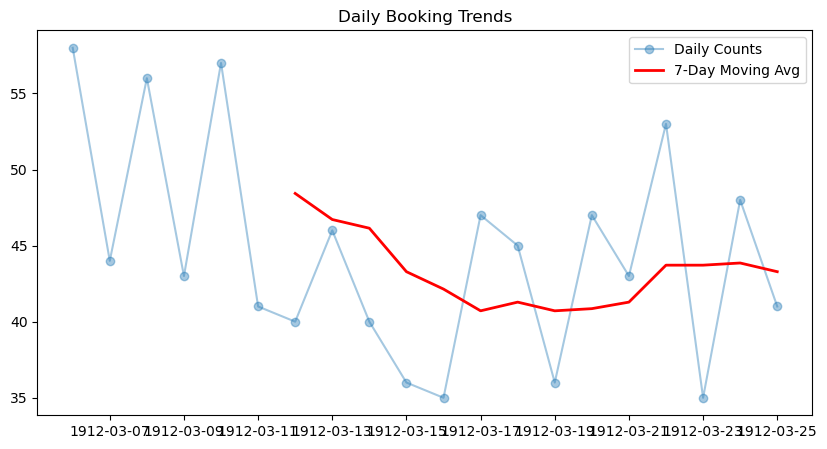

              Daily     7D_Avg
Booking_Date                  
1912-03-06       58        NaN
1912-03-07       44        NaN
1912-03-08       56        NaN
1912-03-09       43        NaN
1912-03-10       57        NaN
1912-03-11       41        NaN
1912-03-12       40  48.428571
1912-03-13       46  46.714286
1912-03-14       40  46.142857
1912-03-15       36  43.285714


In [9]:
"""Task 1: Compute a 7‑day moving average of daily using .rolling(). 
Plot the original daily counts and the moving average on the same chart 
(use .plot() if you'd like, or just display the first 10 rows)."""

# 1. Compute the 7-day moving average
# Rolling(window=7) looks at the current day and the 6 preceding days
moving_avg = daily.rolling(window=7).mean()

# 2. Plotting the data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(daily.index, daily, label='Daily Counts', alpha=0.4, marker='o')
plt.plot(moving_avg.index, moving_avg, label='7-Day Moving Avg', color='red', linewidth=2)

plt.title('Daily Booking Trends')
plt.legend()
plt.show()

# 3. Display the first 10 rows
print(pd.DataFrame({'Daily': daily, '7D_Avg': moving_avg}).head(10))


In [10]:
#Task 2: Compute the 7‑day rolling sum of bookings. Which day had the highest 7‑day total?

max_book = daily.rolling(window=7).sum()

print(f'Day with highest 7-day total: Date {max_book.idxmax()}; Total:{max_book.max()}')


Day with highest 7-day total: Date 1912-03-12 00:00:00; Total:339.0


In [11]:
"""Task 3: Use .rolling() with center=True to compute a 3‑day centered moving average. 
Observe how the NaN values are distributed."""

result = daily.rolling(window=3, center=True).mean()
result


Booking_Date
1912-03-06          NaN
1912-03-07    52.666667
1912-03-08    47.666667
1912-03-09    52.000000
1912-03-10    47.000000
1912-03-11    46.000000
1912-03-12    42.333333
1912-03-13    42.000000
1912-03-14    40.666667
1912-03-15    37.000000
1912-03-16    39.333333
1912-03-17    42.333333
1912-03-18    42.666667
1912-03-19    42.666667
1912-03-20    42.000000
1912-03-21    47.666667
1912-03-22    43.666667
1912-03-23    45.333333
1912-03-24    41.333333
1912-03-25          NaN
Freq: D, Name: PassengerId, dtype: float64

In [12]:
"""Task 4 (Bonus): Create a rolling standard deviation (volatility) of daily bookings with a 
window of 5 days. Which period was the most volatile?"""

result = daily.rolling(window=5).std()

print(f"The most volatile 5-day period ended on: {result.idxmax().date()}.")
print(f"Standard Deviation at peak: {result.max()}")


The most volatile 5-day period ended on: 1912-03-12.
Standard Deviation at peak: 8.384509526501834


In [13]:
#Day 6, Topic 6: Shifting and Lagging
#Basic .shift() – Lagging (Shifting Down)
import pandas as pd
import numpy as np

dates = pd.date_range('2024-01-01', periods=5, freq='D')
values = pd.Series([10, 20, 30, 40, 50], index=dates)
print("Original:")
print(values)

#Shift by 1 (lag)
lagged = values.shift(1)
print("\nLagged (Shift 1):")
print(lagged)

Original:
2024-01-01    10
2024-01-02    20
2024-01-03    30
2024-01-04    40
2024-01-05    50
Freq: D, dtype: int64

Lagged (Shift 1):
2024-01-01     NaN
2024-01-02    10.0
2024-01-03    20.0
2024-01-04    30.0
2024-01-05    40.0
Freq: D, dtype: float64


In [14]:
#Negative Shift – Leading (Shifting Up)
lead = values.shift(-1)
print("Lead (shift -1):")
print(lead)

Lead (shift -1):
2024-01-01    20.0
2024-01-02    30.0
2024-01-03    40.0
2024-01-04    50.0
2024-01-05     NaN
Freq: D, dtype: float64


In [15]:
#Calculating Period‑over‑Period Changes
daily_change = values.diff()
print("Day-over-Day change:")
print(daily_change)

Day-over-Day change:
2024-01-01     NaN
2024-01-02    10.0
2024-01-03    10.0
2024-01-04    10.0
2024-01-05    10.0
Freq: D, dtype: float64


In [16]:
#Shifting on a DataFrame
df = pd.DataFrame({
    'A': [1, 2, 3, 4],
    'B': [5, 6, 7, 8]
})

df_lagged = df.shift(2)
df_lagged

,A,B
0,NaN,NaN
1,NaN,NaN
2,1.0,5.0
3,2.0,6.0


In [17]:
#Shifting with freq (DatetimeIndex Only)
monthly = pd.Series([1, 2, 3], index=pd.date_range('2024-01-01', periods=3, freq='MS'))
shifted = monthly.shift(1, freq='M')
shifted

C:\Users\Faizan Toheed\AppData\Local\Temp\ipykernel_14748\1721588035.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  shifted = monthly.shift(1, freq='M')


2024-01-31    1
2024-02-29    2
2024-03-31    3
dtype: int64

In [18]:
#Practice Activity: Shifting and Lagging
import pandas as pd
import numpy as np


df = pd.read_csv('titanic.csv')

departure = pd.to_datetime('1912-04-15')
np.random.seed(42)
df['Booking_Date'] = departure - pd.Timedelta(days=30) + pd.to_timedelta(np.random.randint(-10, 10, size=len(df)), unit='D')

df_indexed = df.set_index('Booking_Date')
daily = df_indexed.resample('D')['PassengerId'].count().fillna(0)
daily.head(10)

Booking_Date
1912-03-06    58
1912-03-07    44
1912-03-08    56
1912-03-09    43
1912-03-10    57
1912-03-11    41
1912-03-12    40
1912-03-13    46
1912-03-14    40
1912-03-15    36
Freq: D, Name: PassengerId, dtype: int64

In [19]:
"""Task 1: Create a new Series yesterday that contains the booking counts from the previous day using .shift(1). 
Display the first 5 rows of daily and yesterday side by side."""

yesterday = daily.shift(1)
comparison = pd.DataFrame({
    'Daily': daily,
    'Yesterday': yesterday
})
comparison.head(5)

,Daily,Yesterday
Booking_Date,,
1912-03-06,58,NaN
1912-03-07,44,58.0
1912-03-08,56,44.0
1912-03-09,43,56.0
1912-03-10,57,43.0


In [20]:
"""Task 2: Calculate the day‑over‑day change in bookings using .diff(). 
On which date did the largest absolute change occur? 
(Use .abs().idxmax() to find the date of the largest absolute change.)"""

dod_change = daily.diff()
dod_change.head(10)
max_change_date = dod_change.abs().idxmax()
max_change_value = dod_change[max_change_date]
print(f"\nLargest absolute change occurred on: {max_change_date.date()}")
print(f"Change value: {max_change_value}")


Largest absolute change occurred on: 1912-03-23
Change value: -18.0


In [21]:
# ============================================================================
# Task 3: DataFrame with lag_1 and lag_2
# ============================================================================
lag_df = pd.DataFrame({
    'bookings': daily,
    'lag_1': daily.shift(1),
    'lag_2': daily.shift(2)
})
print("\n=== Task 3: Lagged DataFrame ===")
print(lag_df.head(10))


=== Task 3: Lagged DataFrame ===
              bookings  lag_1  lag_2
Booking_Date                        
1912-03-06          58    NaN    NaN
1912-03-07          44   58.0    NaN
1912-03-08          56   44.0   58.0
1912-03-09          43   56.0   44.0
1912-03-10          57   43.0   56.0
1912-03-11          41   57.0   43.0
1912-03-12          40   41.0   57.0
1912-03-13          46   40.0   41.0
1912-03-14          40   46.0   40.0
1912-03-15          36   40.0   46.0


In [22]:
"""Task 4 (Bonus): If daily were monthly data (resample to 'M' and sum), 
use .shift(freq='M') to shift the entire series forward by one calendar month. Observe how the dates change."""

monthly = daily.resample('ME').sum()
monthly_shifted = monthly.shift(1, freq='ME')
print("\n=== Task 4 (Bonus): Monthly Shift ===")
print("Original monthly:")
print(monthly)
print("\nShifted by 1 month (freq='ME'):")
print(monthly_shifted)


=== Task 4 (Bonus): Monthly Shift ===
Original monthly:
Booking_Date
1912-03-31    891
Freq: ME, Name: PassengerId, dtype: int64

Shifted by 1 month (freq='ME'):
Booking_Date
1912-04-30    891
Freq: ME, Name: PassengerId, dtype: int64


In [23]:
#Day 6, Topic 7: Time Zone Handling
import pandas as pd

In [24]:
#Naive vs. Time Zone‑Aware Datetimes
naive = pd.to_datetime('2024-01-01 09:00:00')
print(f"Naive {naive}, tz={naive.tz}")

Naive 2024-01-01 09:00:00, tz=None


In [25]:
#Localizing – Adding a Time Zone with .tz_localize()
my_time = naive.tz_localize('Asia/Karachi')
print(f"Karachi Time: {my_time}, tz={my_time.tz}")

Karachi Time: 2024-01-01 09:00:00+05:00, tz=Asia/Karachi


In [26]:
#Converting Between Time Zones with .tz_convert()
new_york = my_time.tz_convert('America/New_York')
print(f"NewYork Time: {new_york}, tz={new_york.tz}")

NewYork Time: 2023-12-31 23:00:00-05:00, tz=America/New_York


In [27]:
#Working with Entire Series/DataFrames
departures = pd.Series(pd.to_datetime(['2024-01-01 08:00', '2024-01-01 15:30', '2024-01-02 22:15']))

departures_ny = departures.dt.tz_localize('America/New_York')
departures_utc = departures_ny.dt.tz_convert('UTC')


df = pd.DataFrame({
    'NY_departure': departures_ny,
    'UTC': departures_utc
})

df

,NY_departure,UTC
0,2024-01-01 08:00:00-05:00,2024-01-01 13:00:00+00:00
1,2024-01-01 15:30:00-05:00,2024-01-01 20:30:00+00:00
2,2024-01-02 22:15:00-05:00,2024-01-03 03:15:00+00:00


In [28]:
#Removing Time Zone with .tz_localize(None)
naive_again = departures_ny.dt.tz_localize(None)

In [29]:
# A date in summer (EDT, UTC-4) vs winter (EST, UTC-5)
summer = pd.to_datetime('2024-07-01 12:00').tz_localize('America/New_York')
winter = pd.to_datetime('2024-01-01 12:00').tz_localize('America/New_York')

print(f"Summer: {summer}, offset: {summer.utcoffset()}")

Summer: 2024-07-01 12:00:00-04:00, offset: -1 day, 20:00:00


In [30]:
#Practice Activity: Time Zone Handling
import pandas as pd
import numpy as np


df = pd.read_csv('titanic.csv')

departure = pd.to_datetime('1912-04-15')
np.random.seed(42)
df['Booking_Date'] = departure - pd.Timedelta(days=30) + pd.to_timedelta(np.random.randint(-10, 10, size=len(df)), unit='D')

# For time zone practice, add a specific time (noon UTC) to the Booking_Date
df['Booking_DateTime'] = pd.to_datetime(df['Booking_Date'].astype(str) + ' 12:00:00')
df[['Booking_Date', 'Booking_DateTime']].head(10)

,Booking_Date,Booking_DateTime
0,1912-03-12,1912-03-12 12:00:00
1,1912-03-25,1912-03-25 12:00:00
2,1912-03-20,1912-03-20 12:00:00
3,1912-03-16,1912-03-16 12:00:00
4,1912-03-13,1912-03-13 12:00:00
5,1912-03-12,1912-03-12 12:00:00
6,1912-03-24,1912-03-24 12:00:00
7,1912-03-16,1912-03-16 12:00:00
8,1912-03-16,1912-03-16 12:00:00
9,1912-03-09,1912-03-09 12:00:00


In [31]:
#Task 1: Localize the Booking_DateTime column to UTC (it's currently naive).
#  Verify the tz attribute of the first element.

df['Booking_UTC'] = df['Booking_DateTime'].dt.tz_localize('UTC')
df['Booking_UTC'].head()
df['Booking_UTC'].iloc[0]

Timestamp('1912-03-12 12:00:00+0000', tz='UTC')

In [32]:
#Task 2: Convert the UTC‑aware datetimes to 'America/New_York' (Eastern Time). Create a new column Booking_NY.

df['Booking_NY'] = df['Booking_UTC'].dt.tz_convert('America/New_York')

df['Booking_NY'].head()

0   1912-03-12 07:00:00-05:00
1   1912-03-25 07:00:00-05:00
2   1912-03-20 07:00:00-05:00
3   1912-03-16 07:00:00-05:00
4   1912-03-13 07:00:00-05:00
Name: Booking_NY, dtype: datetime64[ns, America/New_York]

In [33]:
#Task 3: What was the New York local hour of the first 5 bookings? Extract it using .dt.hour on the Booking_NY column.

df['NY_hour'] = df['Booking_NY'].dt.hour
df[['Booking_NY', 'NY_hour']].head()

,Booking_NY,NY_hour
0,1912-03-12 07:00:00-05:00,7
1,1912-03-25 07:00:00-05:00,7
2,1912-03-20 07:00:00-05:00,7
3,1912-03-16 07:00:00-05:00,7
4,1912-03-13 07:00:00-05:00,7


In [34]:
"""Task 4 (Bonus): Convert the Booking_NY column to 'Asia/Karachi' time. For the first 5 rows, 
display the original UTC time, NY time, and Karachi time side by side."""

df['Karachi_Time'] = df['Booking_NY'].dt.tz_convert('Asia/Karachi')

df[['Booking_UTC', 'Booking_NY', 'Karachi_Time']].head()

,Booking_UTC,Booking_NY,Karachi_Time
0,1912-03-12 12:00:00+00:00,1912-03-12 07:00:00-05:00,1912-03-12 17:30:00+05:30
1,1912-03-25 12:00:00+00:00,1912-03-25 07:00:00-05:00,1912-03-25 17:30:00+05:30
2,1912-03-20 12:00:00+00:00,1912-03-20 07:00:00-05:00,1912-03-20 17:30:00+05:30
3,1912-03-16 12:00:00+00:00,1912-03-16 07:00:00-05:00,1912-03-16 17:30:00+05:30
4,1912-03-13 12:00:00+00:00,1912-03-13 07:00:00-05:00,1912-03-13 17:30:00+05:30


In [35]:
#Day 6, Topic 8: Date Ranges

import pandas as pd

In [36]:
#Basic pd.date_range()
week_dates = pd.date_range(start='2024-01-01', periods=7, freq='D')
week_dates

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07'],
              dtype='datetime64[ns]', freq='D')

In [37]:
#Example: Business days in January 2024
business_days = pd.date_range('2024-01-01', '2024-01-31', freq='B')
business_days[:5]

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05'],
              dtype='datetime64[ns]', freq='B')

In [38]:
#Creating a DataFrame Index with Date Range
dates = pd.date_range('2024-01-01', periods=5, freq='D')
df = pd.DataFrame({
    'Sales': [100, 150, 200, 250, 300]}, index=dates)
df

,Sales
2024-01-01,100
2024-01-02,150
2024-01-03,200
2024-01-04,250
2024-01-05,300


In [39]:
#Using pd.date_range() with Time Zones
ny_dates = pd.date_range('2024-01-01', periods=3, freq='D', tz='America/New_York')
ny_dates

DatetimeIndex(['2024-01-01 00:00:00-05:00', '2024-01-02 00:00:00-05:00',
               '2024-01-03 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', freq='D')

In [40]:
#Practice Activity: Date Ranges
import pandas as pd

In [41]:
#Task 1: Generate a sequence of all Sundays in January 2024. Use pd.date_range() with appropriate start, end, and freq

pd.date_range('2024-01-01', end='2024-02-01', freq='W-SUN')


DatetimeIndex(['2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28'], dtype='datetime64[ns]', freq='W-SUN')

In [42]:
#Task 2: Create a date range of 10 business days starting from '2024-02-01'. Store it in a variable b_days.

bdays = pd.date_range('2024-02-01', periods=10, freq='B')
bdays

DatetimeIndex(['2024-02-01', '2024-02-02', '2024-02-05', '2024-02-06',
               '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-12',
               '2024-02-13', '2024-02-14'],
              dtype='datetime64[ns]', freq='B')

In [43]:
#Task 3: Create a DataFrame with index b_days and a column 'Value' containing the numbers 1 to 10. Display it.
df = pd.DataFrame({'Values': range(1, 11)}, index=bdays)
df

,Values
2024-02-01,1
2024-02-02,2
2024-02-05,3
2024-02-06,4
2024-02-07,5
2024-02-08,6
2024-02-09,7
2024-02-12,8
2024-02-13,9
2024-02-14,10


In [44]:
#Task 4 (Bonus): Generate a range of 4 month‑end dates starting from January 2024. Then convert it to a list of strings in the format 'YYYY-MM-DD'.

# Generate 4 month-end dates
month_ends = pd.date_range(start='2024-01-01', periods=4, freq='ME')

# Convert to list of strings
date_strings = month_ends.strftime('%Y-%m-%d').tolist()
print(date_strings)

['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30']
